# How do sex education policy and minor access to sexual healthcare relate to HIV incidence across U.S. states?
We have CDC data on socioeconomic factors (uninsured, below poverty level), SIECUS data on sex education mandates (2017, 2018, 2022), and LawAtlas data on minor access to sexual healthcare (parental consent, confidentiality, PrEP-specific access, age of medical consent) all against CDC data on HIV incidence (by state and year).

In [164]:
import pandas as pd
import numpy as np
import re # regex
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# panel regression
from linearmodels.panel import PanelOLS

# PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# causal forests
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

## 1) Clean and merge data

### a) HIV incidence data

In [165]:
# HIV data is poorly formatted; needs to skip rows
hiv = pd.read_csv("/Users/anahumr/Desktop/Python HIV Analysis/data/HIV_states_raw.csv",skiprows=15)

# check if read in correctly
# print(hiv.head())
# print(hiv.columns)
# print(hiv.shape)

# define a helper function to get our percentages out cleanly
def extract_numeric(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x)
    
    # find first number and keep it
    match = re.search(r"[-+]?\d*\.?\d+", x)
    
    if match:
        return float(match.group())
    return np.nan
    
hiv["Percent (95% CI RSE)"] = hiv["Percent (95% CI RSE)"].apply(extract_numeric)

hiv_panel = hiv[hiv["Indicator"].isin([
    "HIV viral suppression",
    "Knowledge of Status",
    "Receipt of HIV medical care"
])]

hiv_panel = hiv_panel.pivot_table(
    index=["Geography", "FIPS", "Year"],
    columns="Indicator",
    values="Percent (95% CI RSE)"
).reset_index()

hiv_panel["Year"] = hiv_panel["Year"].astype(str).str.extract(r"(\d{4})")
hiv_panel["Year"] = hiv_panel["Year"].astype(int)

### b) Socioeconomic factors data

In [166]:
socio = pd.read_csv("/Users/anahumr/Desktop/Python HIV Analysis/data/social_risk_states_raw.csv", skiprows = 7)

# good!
# print(socio.head())
# print(socio.columns)
# print(socio.shape)

#good!
# socio["Indicator"].value_counts()

# just make sure something like 400,000 reads as 400000
socio["Numerator"] = socio["Numerator"].str.replace(",", "")
socio["Numerator"] = pd.to_numeric(socio["Numerator"], errors="coerce")

# make it a pivot table for merging
socio_wide = socio.pivot_table(
    index=["Geography", "Year"],
    columns="Indicator",
    values="Percent"
).reset_index()

# rename for ease
socio_wide = socio_wide.rename(columns={
    "Uninsured": "uninsured_pct",
    "Households living below the federal poverty level": "poverty_pct"
})

# make sure years are nums too (but keep 2020 even though it has words after)
socio_wide["Year"] = socio_wide["Year"].astype(str).str.extract(r"(\d{4})")
socio_wide["Year"] = socio_wide["Year"].astype(int)

# check that it matches for merging
# print(socio_wide.head())
# print(socio_wide.shape)

# merge socio and HIV
merged = pd.merge(
    hiv_panel,
    socio_wide,
    on=["Geography", "Year"],
    how="left")

# verify!
merged[merged["Geography"] == "Alabama"].head(10)

Indicator,Geography,FIPS,Year,HIV viral suppression,Knowledge of Status,Receipt of HIV medical care,poverty_pct,uninsured_pct
0,Alabama,1,2017,63.6,81.3,75.7,12.8,9.4
1,Alabama,1,2018,65.9,81.7,77.4,12.2,10.0
2,Alabama,1,2019,66.7,82.5,78.0,11.2,9.7
3,Alabama,1,2020,65.4,83.1,75.6,9.8,9.7
4,Alabama,1,2021,59.1,82.8,71.9,11.7,9.9
5,Alabama,1,2022,54.1,83.0,73.7,12.0,8.8


### c) Minor medical access policy data

In [167]:
laws = pd.read_csv("/Users/anahumr/Desktop/Python HIV Analysis/data/minor_access_states_raw.csv")

# parse dates
laws["Effective Date"] = pd.to_datetime(laws["Effective Date"], errors="coerce")
laws["Valid Through Date"] = pd.to_datetime(laws["Valid Through Date"], errors="coerce")

# drop invalid dates
laws = laws.dropna(subset=["Effective Date", "Valid Through Date"])

# extract years
laws["start_year"] = laws["Effective Date"].dt.year
laws["end_year"]   = laws["Valid Through Date"].dt.year

# filter out rows outside the range
laws_filtered = laws[
    (laws["end_year"] >= 2017) &   # ends in or after 2017
    (laws["start_year"] <= 2022)   # starts in or before 2022
].copy()
    
# rename for merging
laws_filtered = laws_filtered.rename(columns={"State": "Geography"})

laws_filtered = (
    laws_filtered.assign(
        Year=laws_filtered.apply(
            lambda r: list(range(r["start_year"], r["end_year"] + 1)),
            axis=1
        )
    )
    .explode("Year") # filter and expand so I have one per year the law was active
)

# make years ints
laws_filtered["Year"] = laws_filtered["Year"].astype(int)

laws_filtered = laws_filtered[ # remove the 2005, 2006, 2007...
    (laws_filtered["Year"] >= 2017) &
    (laws_filtered["Year"] <= 2022)
]

# verify
# laws_filtered.head(20)

# verify we preserved the interesting things
cols = ["stitest_confidential","stitreat_confidential","hivtest_confidential","hivtreat_confidential","prep_confidential"]
for c in cols:
    print(c, laws_filtered[c].value_counts(dropna=False), "\n")

stitest_confidential stitest_confidential
0    139
1    120
Name: count, dtype: int64 

stitreat_confidential stitreat_confidential
0    144
1    115
Name: count, dtype: int64 

hivtest_confidential hivtest_confidential
0    149
1    110
Name: count, dtype: int64 

hivtreat_confidential hivtreat_confidential
0    144
1    115
Name: count, dtype: int64 

prep_confidential prep_confidential
2    92
0    90
1    77
Name: count, dtype: int64 



### Categorize minor medical access policy
Based on the codebook, we're interested in:
1) Minor consent to HIV/STI prevention
2) Minor confidentiality index
3) Age restriction index

Create some at-a-glance variables for those categories, but these variables will likely be used individually or as components later.

In [168]:
# 1) minor consent rights. 0 is "yes, a minor can consent," 1 is "no"
laws_filtered["consent_prevention"] = (
    (laws_filtered["hivprev"] == 0) | 
    (laws_filtered["prep"] == 0) |
    (laws_filtered["pep"] == 0)).astype(int)
    
    #(laws_filtered["stiprev"] == 0)).astype(int)

# 2) Minor confidentiality
laws_filtered["confidentiality"] = (
    (laws_filtered["stitest_confidential"] == 0) |
    (laws_filtered["hivtest_confidential"] == 0) |
    (laws_filtered["hivtreat_confidential"] == 0) |
    (laws_filtered["prep_confidential"] == 0)).astype(int)

# (laws_filtered["stitreat_confidential"] == 0) |

# 4) Age restrictions
age_cols_men = [
    "stitest_agemaj_men",
    "hivtest_agemaj_men",
    "hivtreat_agemaj_men",
    "hivprev_agemaj_men",
    "prep_agemaj_men"]
age_cols_women = [
    "stitest_agemaj_women",
    "hivtest_agemaj_women",
    "hivtreat_agemaj_women",
    "hivprev_agemaj_women",
    "prep_agemaj_women"]

# capture the greatest legal age ("most restrictive" law for each)
laws_filtered["restrictive_cnst_age_men"] = (
    laws_filtered[age_cols_men]
    .replace(26, np.nan) # also codebook 26 is N/A
    .max(axis=1))
laws_filtered["restrictive_cnst_age_women"] = (
    laws_filtered[age_cols_women]
    .replace(26, np.nan)
    .max(axis=1))

# capture the lowest legal age ("most permissive" law for each)
laws_filtered["permissive_cnst_age_men"] = (
    laws_filtered[age_cols_men]
    .replace(26, np.nan) # also codebook 26 is N/A
    .min(axis=1))
laws_filtered["permissive_cnst_age_women"] = (
    laws_filtered[age_cols_women]
    .replace(26, np.nan)
    .min(axis=1))

# verify we preserved the interesting things
cols = ["consent_prevention","confidentiality","restrictive_cnst_age_men","restrictive_cnst_age_women","permissive_cnst_age_men","permissive_cnst_age_women"]
for c in cols:
    print(c, laws_filtered[c].value_counts(dropna=False), "\n")

consent_prevention consent_prevention
1    168
0     91
Name: count, dtype: int64 

confidentiality confidentiality
1    159
0    100
Name: count, dtype: int64 

restrictive_cnst_age_men restrictive_cnst_age_men
0     123
18     97
14     17
12      7
13      5
15      5
16      5
Name: count, dtype: int64 

restrictive_cnst_age_women restrictive_cnst_age_women
0     123
18     97
14     17
12      7
13      5
15      5
16      5
Name: count, dtype: int64 

permissive_cnst_age_men permissive_cnst_age_men
0     224
14     20
12     15
Name: count, dtype: int64 

permissive_cnst_age_women permissive_cnst_age_women
0     224
14     20
12     15
Name: count, dtype: int64 



In [169]:
# merge!
merged_no_sex_ed = pd.merge(
    merged,
    laws_filtered,
    on=["Geography", "Year"],
    how="left")

# get rid of leftover year calculation columns
merged_no_sex_ed = merged_no_sex_ed.drop(columns=[
    "Effective Date",
    "Valid Through Date",
    "start_year",
    "end_year"])

print(merged_no_sex_ed.columns.tolist())

['Geography', 'FIPS', 'Year', 'HIV viral suppression', 'Knowledge of Status', 'Receipt of HIV medical care', 'poverty_pct', 'uninsured_pct', 'age_maj_men', 'age_maj_women', 'healthcare', 'healthcare_conditions', 'healthcare_conditions_text', 'healthcare_sti', 'healthcare_sticat Testing', 'healthcare_sticat Treatment', 'healthcare_sticat Prevention', 'healthcare_sticat N/A', 'healthcare_hiv', 'healthcare_hivcat Testing', 'healthcare_hivcat Treatment', 'healthcare_hivcat Prevention', 'healthcare_hivcat N/A', 'healthcare_mental', 'healthcare_sud', 'healthcare_confidential', 'healthcare_confidential_conditions', 'healthcare_disclose', 'healthcare_agemaj_men', 'healthcare_agemaj_women', 'stitest', 'stitest_conditions', 'stitest_conditions_text', 'stitest_confidential', 'stitest_confidential_conditions', 'stitest_disclose', 'stitest_disclose_result', 'stitest_agemaj_men', 'stitest_agemaj_women', 'stitreat', 'stitreat_conditions', 'stitreat_conditions_text', 'stitreat_confidential', 'stitreat

### c) Sex Ed Mandate Data
0 = not mandated
1 = mandated

In [170]:
ed = pd.read_csv("/Users/anahumr/Desktop/Python HIV Analysis/data/state_sex_ed_HIV_raw.csv")

# rename for merging
ed = ed.rename(columns={
    "state": "Geography",
    "year": "Year"})

merged = merged_no_sex_ed.merge(
    ed,
    on=["Geography", "Year"],
    how="left")

# this was improperly named
merged = merged.drop(columns=["sex_ed_mandate"])

# verify
merged.head(5)

,Geography,FIPS,Year,HIV viral suppression,Knowledge of Status,Receipt of HIV medical care,poverty_pct,uninsured_pct,age_maj_men,age_maj_women,...,payor,payor_conditions,payor_conditions_text,consent_prevention,confidentiality,restrictive_cnst_age_men,restrictive_cnst_age_women,permissive_cnst_age_men,permissive_cnst_age_women,hiv_ed_mandate
0,Alabama,1,2017,63.6,81.3,75.7,12.8,9.4,19.0,19.0,...,1.0,2.0,NaN,1.0,0.0,14.0,14.0,0.0,0.0,1.0
1,Alabama,1,2018,65.9,81.7,77.4,12.2,10.0,19.0,19.0,...,1.0,2.0,NaN,1.0,0.0,14.0,14.0,0.0,0.0,1.0
2,Alabama,1,2019,66.7,82.5,78.0,11.2,9.7,19.0,19.0,...,1.0,2.0,NaN,1.0,0.0,14.0,14.0,0.0,0.0,NaN
3,Alabama,1,2020,65.4,83.1,75.6,9.8,9.7,19.0,19.0,...,1.0,2.0,NaN,1.0,0.0,14.0,14.0,0.0,0.0,NaN
4,Alabama,1,2021,59.1,82.8,71.9,11.7,9.9,19.0,19.0,...,1.0,2.0,NaN,1.0,0.0,14.0,14.0,0.0,0.0,NaN


## 2) Begin testing panel and fixed-effect regressions.

### a) Setup

In [171]:
df = merged.copy()
print(df.columns.tolist())

# get correlation matrix
df[[
    "consent_prevention",
    "confidentiality",
    "restrictive_cnst_age_men",
    "restrictive_cnst_age_women",
    "permissive_cnst_age_men",
    "permissive_cnst_age_women",
    "poverty_pct",
    "uninsured_pct",
    "hiv_ed_mandate"
]].corr()

['Geography', 'FIPS', 'Year', 'HIV viral suppression', 'Knowledge of Status', 'Receipt of HIV medical care', 'poverty_pct', 'uninsured_pct', 'age_maj_men', 'age_maj_women', 'healthcare', 'healthcare_conditions', 'healthcare_conditions_text', 'healthcare_sti', 'healthcare_sticat Testing', 'healthcare_sticat Treatment', 'healthcare_sticat Prevention', 'healthcare_sticat N/A', 'healthcare_hiv', 'healthcare_hivcat Testing', 'healthcare_hivcat Treatment', 'healthcare_hivcat Prevention', 'healthcare_hivcat N/A', 'healthcare_mental', 'healthcare_sud', 'healthcare_confidential', 'healthcare_confidential_conditions', 'healthcare_disclose', 'healthcare_agemaj_men', 'healthcare_agemaj_women', 'stitest', 'stitest_conditions', 'stitest_conditions_text', 'stitest_confidential', 'stitest_confidential_conditions', 'stitest_disclose', 'stitest_disclose_result', 'stitest_agemaj_men', 'stitest_agemaj_women', 'stitreat', 'stitreat_conditions', 'stitreat_conditions_text', 'stitreat_confidential', 'stitreat

,consent_prevention,confidentiality,restrictive_cnst_age_men,restrictive_cnst_age_women,permissive_cnst_age_men,permissive_cnst_age_women,poverty_pct,uninsured_pct,hiv_ed_mandate
consent_prevention,1.000000,0.213713,-0.791681,-0.791681,-0.208800,-0.208800,0.081161,-0.095559,-0.017339
confidentiality,0.213713,1.000000,-0.212758,-0.212758,-0.285696,-0.285696,0.050236,0.032146,0.072822
restrictive_cnst_age_men,-0.791681,-0.212758,1.000000,1.000000,0.333751,0.333751,-0.004269,0.089200,0.020016
restrictive_cnst_age_women,-0.791681,-0.212758,1.000000,1.000000,0.333751,0.333751,-0.004269,0.089200,0.020016
permissive_cnst_age_men,-0.208800,-0.285696,0.333751,0.333751,1.000000,1.000000,-0.305214,-0.271374,0.096339
permissive_cnst_age_women,-0.208800,-0.285696,0.333751,0.333751,1.000000,1.000000,-0.305214,-0.271374,0.096339
poverty_pct,0.081161,0.050236,-0.004269,-0.004269,-0.305214,-0.305214,1.000000,0.366406,0.058407
uninsured_pct,-0.095559,0.032146,0.089200,0.089200,-0.271374,-0.271374,0.366406,1.000000,-0.131293
hiv_ed_mandate,-0.017339,0.072822,0.020016,0.020016,0.096339,0.096339,0.058407,-0.131293,1.000000


### b) Fixed-Effects Regression

In [172]:
df = df.set_index(["Geography", "Year"]) # observations are state-year

y = df["HIV viral suppression"] # variable of interest (1 of 3)

X = df[[
    "consent_prevention",
    "confidentiality",
    "restrictive_cnst_age_men",
    "restrictive_cnst_age_women",
    "permissive_cnst_age_men",
    "permissive_cnst_age_women",
    "poverty_pct",
    "uninsured_pct",
    "hiv_ed_mandate"
]]

### c) Run panel regressions by year (sanity check; haven't done PCA)

In [173]:
df_year_groups = merged.copy()

# same variables as last time
controls = [
    "consent_prevention",
    "confidentiality",
    "restrictive_cnst_age_men",
    "restrictive_cnst_age_women",
    "permissive_cnst_age_men",
    "permissive_cnst_age_women",
    "poverty_pct",
    "uninsured_pct",
]

results = {}

# loop over years and run regressions
for year in sorted(df_year_groups["Year"].dropna().unique()):

    sub = df_year_groups[df_year_groups["Year"] == year].dropna(subset=["HIV viral suppression"] + controls)

    # skip if too small
    if len(sub) < len(controls) + 5:
        continue

    y = sub["HIV viral suppression"]
    X = sub[controls]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()

    results[year] = model

    print("\n===================================")
    print(f"YEAR: {year}")
    print(model.params)


YEAR: 2017
const                         82.369224
consent_prevention             2.302865
confidentiality               -6.014897
restrictive_cnst_age_men       0.064238
restrictive_cnst_age_women     0.064238
permissive_cnst_age_men       -0.076235
permissive_cnst_age_women     -0.076235
poverty_pct                   -1.429633
uninsured_pct                 -0.171462
dtype: float64

YEAR: 2018
const                         82.365100
consent_prevention             3.128790
confidentiality               -6.399343
restrictive_cnst_age_men       0.119203
restrictive_cnst_age_women     0.119203
permissive_cnst_age_men       -0.109049
permissive_cnst_age_women     -0.109049
poverty_pct                   -1.278976
uninsured_pct                 -0.356737
dtype: float64

YEAR: 2019
const                         82.856827
consent_prevention             4.258137
confidentiality               -3.811571
restrictive_cnst_age_men       0.138230
restrictive_cnst_age_women     0.138230
permissive_cns

## 4) Principal Component Analysis

### a) Run PCA on select variables.

In [174]:
include_cols = [
    "hivtreat",
    "stitreat",
    "hivprev",
    "prep",
    "pep",
    "stiprev",
    "hivtest_confidential",
    "hivtreat_confidential",
    "prep_confidential",
    "stitest_confidential",
    "stitreat_confidential",
    "restrictive_cnst_age_men",
    "restrictive_cnst_age_women",
    "permissive_cnst_age_men",
    "permissive_cnst_age_women",
    "poverty_pct",
    "uninsured_pct"]

df_PCA = merged.copy() # another copy of the data for safekeeping

df_pca = df_PCA.dropna(subset=include_cols).copy() # drop missing vals
X = df_pca[include_cols]

# print(X.describe())

In [175]:
# standardize data for PCA!!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# check how many components would be best--choose 4
print("Explained variance ratio:")
print(np.round(pca.explained_variance_ratio_, 3))

print("\nCumulative:")
print(np.round(np.cumsum(pca.explained_variance_ratio_), 5))

Explained variance ratio:
[0.462 0.231 0.139 0.069 0.042 0.03  0.01  0.009 0.004 0.002 0.002 0.
 0.    0.    0.    0.    0.   ]

Cumulative:
[0.46164 0.69258 0.83126 0.9005  0.94291 0.97268 0.98268 0.99129 0.99561
 0.99797 1.      1.      1.      1.      1.      1.      1.     ]


In [176]:
# PCA with 4 components
pca = PCA(n_components=4)
X_pcs = pca.fit_transform(X_scaled)

# attach them to dataframe
for i in range(4):
    df_pca[f"PC{i+1}"] = X_pcs[:, i]

In [177]:
# closer look at the components and their effects on each PC
loadings = pd.DataFrame( # store for visual use later
    pca.components_.T,
    index=include_cols,
    columns=[f"PC{i+1}" for i in range(4)])

print(loadings["PC2"].sort_values(ascending=False))

stitest_confidential          0.437384
stitreat_confidential         0.428235
hivtreat_confidential         0.428235
hivtest_confidential          0.422655
permissive_cnst_age_women     0.130365
permissive_cnst_age_men       0.130365
hivtreat                     -0.000000
stitreat                     -0.000000
prep_confidential            -0.055773
poverty_pct                  -0.109940
uninsured_pct                -0.121730
restrictive_cnst_age_men     -0.146224
restrictive_cnst_age_women   -0.146224
stiprev                      -0.189250
hivprev                      -0.198525
pep                          -0.198525
prep                         -0.204644
Name: PC2, dtype: float64


### b) Sliced regressions by year with PCA

In [178]:
controls = ["PC1", "PC2", "PC3", "PC4"]
year_models = {}

# run over each year
for year in sorted(df_pca["Year"].dropna().unique()):
    
    sub = df_pca[df_pca["Year"] == year].dropna(subset=["HIV viral suppression"] + controls)
    
    if len(sub) < 20:  # safety check (note: will break on sex ed data)
        continue
    
    X = sm.add_constant(sub[controls])
    y = sub["HIV viral suppression"] # variable of interest
    
    model = sm.OLS(y, X).fit()
    year_models[year] = model

## 2017 PCA

In [179]:
year_models[2017].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     HIV viral suppression   R-squared:                       0.308
Model:                               OLS   Adj. R-squared:                  0.236
Method:                    Least Squares   F-statistic:                     4.238
Date:                   Wed, 22 Apr 2026   Prob (F-statistic):            0.00620
Time:                           21:17:43   Log-Likelihood:                -143.58
No. Observations:                     43   AIC:                             297.2
Df Residuals:                         38   BIC:                             306.0
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.0064      1.145     58.519      0.000      64.688      69.324
PC1            0.6946      0.418      1.662      0.105      -0.152       1.541
PC2            1.7800      0.589      3.020      0.004       0.587       2.973
PC3            0.6552      0.765      0.856      0.397      -0.894       2.204
PC4           -2.1991      1.024     -2.147      0.038      -4.272      -0.126
==============================================================================
Omnibus:                        0.356   Durbin-Watson:                   1.903
Prob(Omnibus):                  0.837   Jarque-Bera (JB):                0.522
Skew:                          -0.156   Prob(JB):                        0.770
Kurtosis:                       2.559   Cond. No.                         2.87
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 2018 PCA

In [180]:
year_models[2018].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     HIV viral suppression   R-squared:                       0.357
Model:                               OLS   Adj. R-squared:                  0.289
Method:                    Least Squares   F-statistic:                     5.272
Date:                   Wed, 22 Apr 2026   Prob (F-statistic):            0.00177
Time:                           21:17:43   Log-Likelihood:                -139.47
No. Observations:                     43   AIC:                             288.9
Df Residuals:                         38   BIC:                             297.8
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         68.1759      1.022     66.701      0.000      66.107      70.245
PC1            0.8050      0.370      2.174      0.036       0.056       1.555
PC2            1.8380      0.553      3.321      0.002       0.717       2.958
PC3            0.5642      0.685      0.824      0.415      -0.822       1.951
PC4           -1.9738      0.957     -2.064      0.046      -3.910      -0.037
==============================================================================
Omnibus:                        1.220   Durbin-Watson:                   1.952
Prob(Omnibus):                  0.543   Jarque-Bera (JB):                1.008
Skew:                          -0.129   Prob(JB):                        0.604
Kurtosis:                       2.295   Cond. No.                         2.84
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 2019 PCA

In [181]:
year_models[2019].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     HIV viral suppression   R-squared:                       0.279
Model:                               OLS   Adj. R-squared:                  0.210
Method:                    Least Squares   F-statistic:                     4.063
Date:                   Wed, 22 Apr 2026   Prob (F-statistic):            0.00713
Time:                           21:17:43   Log-Likelihood:                -159.32
No. Observations:                     47   AIC:                             328.6
Df Residuals:                         42   BIC:                             337.9
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.8066      1.115     60.789      0.000      65.556      70.058
PC1            0.5333      0.409      1.304      0.199      -0.292       1.359
PC2            1.4109      0.618      2.281      0.028       0.163       2.659
PC3            1.2835      0.772      1.663      0.104      -0.274       2.841
PC4           -2.7372      1.047     -2.614      0.012      -4.850      -0.624
==============================================================================
Omnibus:                        1.353   Durbin-Watson:                   1.893
Prob(Omnibus):                  0.508   Jarque-Bera (JB):                1.022
Skew:                          -0.360   Prob(JB):                        0.600
Kurtosis:                       2.953   Cond. No.                         2.76
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 2020 PCA

In [182]:
year_models[2020].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     HIV viral suppression   R-squared:                       0.293
Model:                               OLS   Adj. R-squared:                  0.224
Method:                    Least Squares   F-statistic:                     4.245
Date:                   Wed, 22 Apr 2026   Prob (F-statistic):            0.00576
Time:                           21:17:43   Log-Likelihood:                -148.81
No. Observations:                     46   AIC:                             307.6
Df Residuals:                         41   BIC:                             316.8
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         65.7942      0.977     67.361      0.000      63.822      67.767
PC1            0.5998      0.376      1.597      0.118      -0.159       1.358
PC2            1.4397      0.534      2.698      0.010       0.362       2.517
PC3            1.3652      0.668      2.044      0.047       0.016       2.714
PC4           -1.9549      0.907     -2.156      0.037      -3.786      -0.124
==============================================================================
Omnibus:                        7.789   Durbin-Watson:                   2.460
Prob(Omnibus):                  0.020   Jarque-Bera (JB):                6.844
Skew:                          -0.764   Prob(JB):                       0.0327
Kurtosis:                       4.111   Cond. No.                         2.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 2021 PCA

In [183]:
year_models[2021].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     HIV viral suppression   R-squared:                       0.341
Model:                               OLS   Adj. R-squared:                  0.280
Method:                    Least Squares   F-statistic:                     5.573
Date:                   Wed, 22 Apr 2026   Prob (F-statistic):            0.00105
Time:                           21:17:43   Log-Likelihood:                -153.44
No. Observations:                     48   AIC:                             316.9
Df Residuals:                         43   BIC:                             326.2
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.8398      0.906     74.901      0.000      66.013      69.666
PC1            0.4310      0.343      1.256      0.216      -0.261       1.123
PC2            1.2617      0.507      2.491      0.017       0.240       2.283
PC3            1.3235      0.611      2.165      0.036       0.090       2.557
PC4           -2.5984      0.851     -3.053      0.004      -4.315      -0.882
==============================================================================
Omnibus:                        1.779   Durbin-Watson:                   2.482
Prob(Omnibus):                  0.411   Jarque-Bera (JB):                1.701
Skew:                          -0.377   Prob(JB):                        0.427
Kurtosis:                       2.470   Cond. No.                         2.71
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Plot Cross-sectional Data

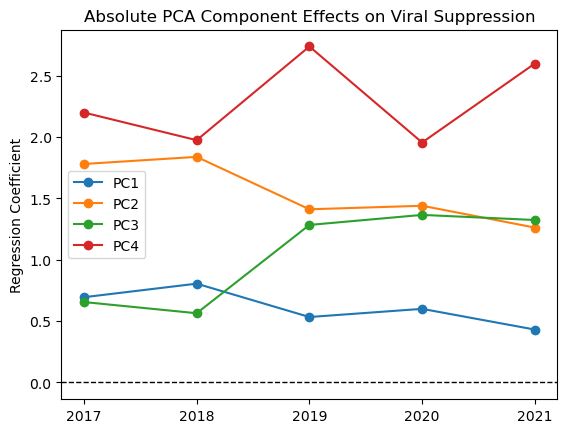

In [184]:
coefs = []
years = []

for year, model in year_models.items():
    # get coefficients for selected variables, take absolute values,
    # and put them in the coefs list
    coefs.append(np.abs(model.params[controls])) # absolute value!
    years.append(int(year))


# make new dataframe so rows are years and cols are controls
coef_df = pd.DataFrame(coefs, index=years)

# sort by year
coef_df = coef_df.sort_index()

#plot!
ax = coef_df.plot(marker='o')

ax.set_xticks(coef_df.index)
ax.set_xticklabels(coef_df.index.astype(int))

plt.axhline(0, linestyle='--', color='black', linewidth=1)
plt.title("Absolute PCA Component Effects on Viral Suppression")
plt.ylabel("Regression Coefficient")
plt.show()

## Pre-COVID (2017 - 2019) and COVID (2020 - 2021) regressions (for fun!)

In [185]:
# get ranges for each side
pre = df_pca[df_pca["Year"].between(2017, 2019)].copy()
post = df_pca[df_pca["Year"].between(2020, 2021)].copy()

pre = pre.dropna(subset=["HIV viral suppression"] + controls)

# add intercept
X_pre = sm.add_constant(pre[controls])
y_pre = pre["HIV viral suppression"] # variable of interest

model_pre = sm.OLS(y_pre, X_pre).fit()

# print!
print("\n==============================")
print("2017–2019 (PRE-COVID)")
model_pre.summary()


2017–2019 (PRE-COVID)


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     HIV viral suppression   R-squared:                       0.304
Model:                               OLS   Adj. R-squared:                  0.282
Method:                    Least Squares   F-statistic:                     13.97
Date:                   Wed, 22 Apr 2026   Prob (F-statistic):           1.74e-09
Time:                           21:17:44   Log-Likelihood:                -444.04
No. Observations:                    133   AIC:                             898.1
Df Residuals:                        128   BIC:                             912.5
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.6956      0.611    110.727      0.000      66.486      68.905
PC1            0.6596      0.224      2.950      0.004       0.217       1.102
PC2            1.6706      0.329      5.074      0.000       1.019       2.322
PC3            0.8580      0.415      2.065      0.041       0.036       1.680
PC4           -2.3429      0.565     -4.150      0.000      -3.460      -1.226
==============================================================================
Omnibus:                        1.796   Durbin-Watson:                   0.868
Prob(Omnibus):                  0.407   Jarque-Bera (JB):                1.840
Skew:                          -0.269   Prob(JB):                        0.398
Kurtosis:                       2.793   Cond. No.                         2.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [186]:
post = post.dropna(subset=["HIV viral suppression"] + controls)

X_post = sm.add_constant(post[controls])
y_post = post["HIV viral suppression"]

model_post = sm.OLS(y_post, X_post).fit()

print("\n==============================")
print("2020–2021 (COVID)")
model_post.summary()


2020–2021 (COVID)


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     HIV viral suppression   R-squared:                       0.300
Model:                               OLS   Adj. R-squared:                  0.268
Method:                    Least Squares   F-statistic:                     9.532
Date:                   Wed, 22 Apr 2026   Prob (F-statistic):           1.85e-06
Time:                           21:17:44   Log-Likelihood:                -303.89
No. Observations:                     94   AIC:                             617.8
Df Residuals:                         89   BIC:                             630.5
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.8068      0.652    102.489      0.000      65.512      68.102
PC1            0.5117      0.250      2.044      0.044       0.014       1.009
PC2            1.3467      0.363      3.711      0.000       0.626       2.068
PC3            1.3109      0.445      2.944      0.004       0.426       2.196
PC4           -2.1575      0.609     -3.545      0.001      -3.367      -0.948
==============================================================================
Omnibus:                        7.081   Durbin-Watson:                   1.337
Prob(Omnibus):                  0.029   Jarque-Bera (JB):                6.516
Skew:                          -0.597   Prob(JB):                       0.0385
Kurtosis:                       3.488   Cond. No.                         2.65
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

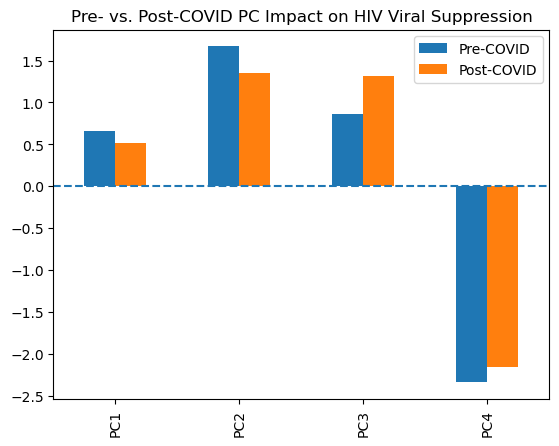

In [187]:
# plot PC impact, as before, on both sets
coef_compare = pd.DataFrame({
    "Pre-COVID": model_pre.params[controls],
    "Post-COVID": model_post.params[controls]
})

coef_compare.plot(kind="bar")
plt.axhline(0, linestyle='--')
plt.title("Pre- vs. Post-COVID PC Impact on HIV Viral Suppression")
plt.show()

## FE regression with PCA
Not the most helpful--our PCA was strongest for structural variance, not inside-state variance.

In [188]:
# panel setup (again, state-year observations)
panel = df_pca.set_index(["Geography", "Year"])

y = panel["HIV viral suppression"] # variable of interest
X = panel[["PC1", "PC2", "PC3", "PC4"]]

model = PanelOLS(
    y,
    X,
    entity_effects=True, # state fixed effects
    time_effects=True # year fixed effects
)

#  clustered standard errors
results = model.fit(cov_type="clustered", cluster_entity=True)

results.summary

/Users/anahumr/miniconda3/envs/mxene/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


Dep. Variable:,HIV viral suppression,R-squared:,0.0791
Estimator:,PanelOLS,R-squared (Between):,-4.6477
No. Observations:,227,R-squared (Within):,0.0606
Date:,"Wed, Apr 22 2026",R-squared (Overall):,-4.4089
Time:,21:17:44,Log-likelihood,-532.57
Cov. Estimator:,Clustered,,
,,F-statistic:,3.6718
Entities:,48,P-value,0.0068
Avg Obs:,4.7292,Distribution:,"F(4,171)"
Min Obs:,1.0000,,
Max Obs:,6.0000,F-statistic (robust):,5.1267


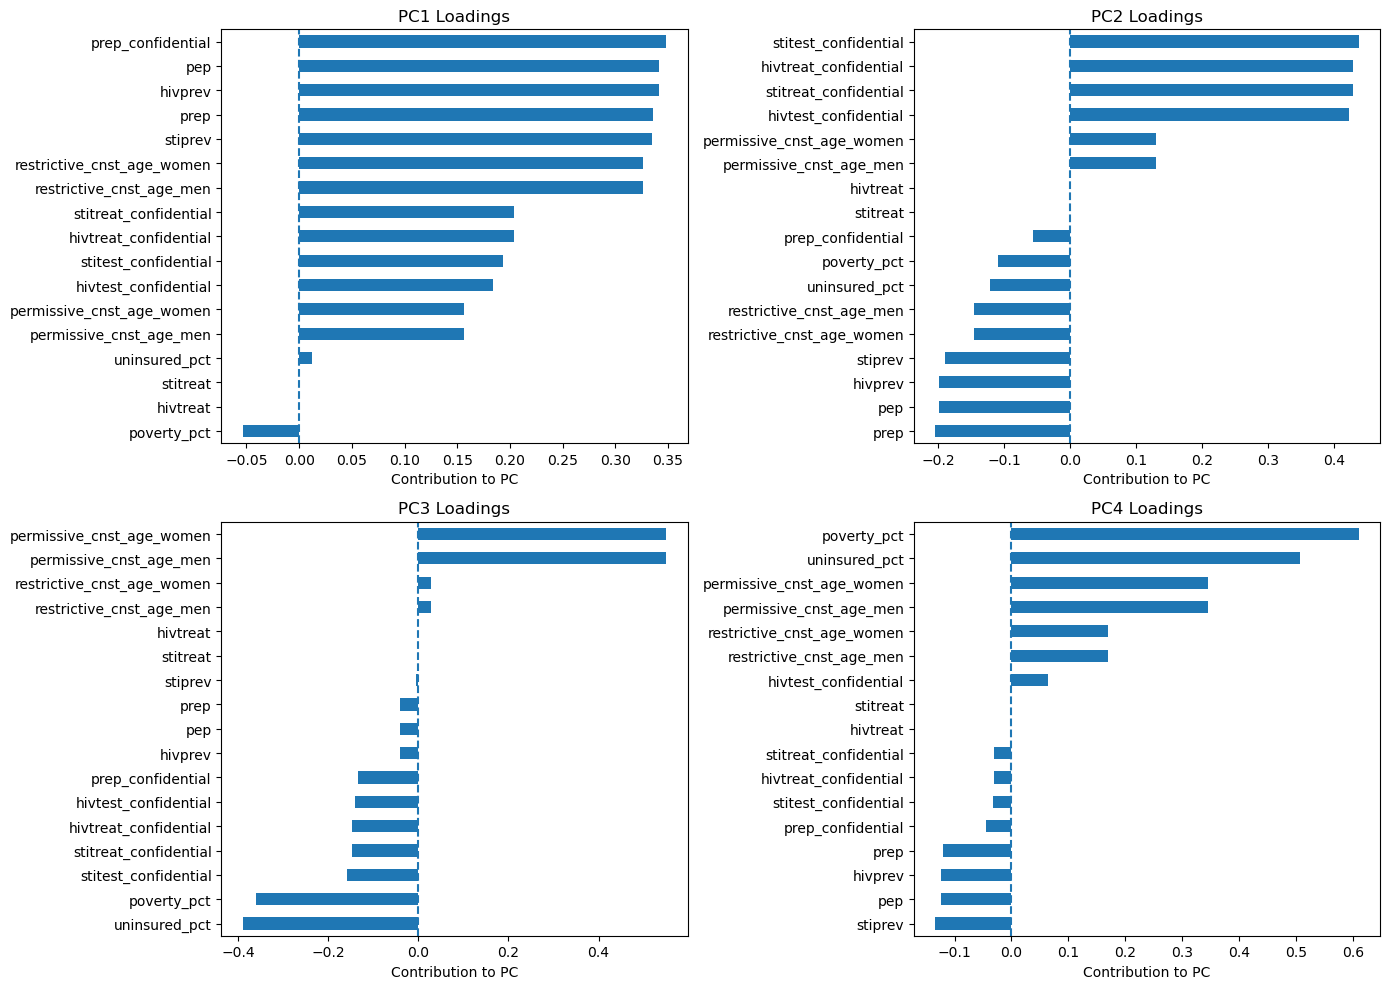

In [189]:
# plot PC loadings!
pcs = ["PC1", "PC2", "PC3", "PC4"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # flatten 2D to 1D

# loop through PCs
for i, pc in enumerate(pcs):
    loadings[pc].sort_values().plot( # sort PC loadings
        kind="barh",
        ax=axes[i] # plot on correct square
    )
    axes[i].set_title(f"{pc} Loadings")
    axes[i].set_xlabel("Contribution to PC")
    axes[i].axvline(0, linestyle="--")

plt.tight_layout()
plt.show()

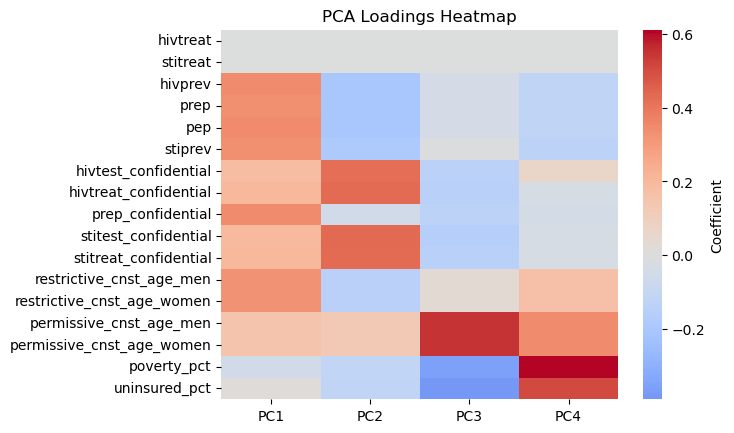

In [190]:
# heatmap of PC loadings
sns.heatmap(
    loadings,
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Coefficient"}
)

plt.title("PCA Loadings Heatmap")
plt.show()

### Run a new PCA for within-state variance.
Run PCA after de-meaning values within each state (average the values, then reassign them as their difference from that mean value).

In [191]:
df_w = df_pca.copy() # another copy for safety

# demean (within transform) data by subtracting the mean from each value (by state)
df_w[include_cols] = df_w[include_cols] - df_w.groupby("Geography")[include_cols].transform("mean")
X_scaled = scaler.fit_transform(df_w[include_cols])

# run PCA again
pca_within = PCA(n_components=4)
X_pcs_within = pca_within.fit_transform(X_scaled)

for i in range(4):
    df_w[f"PCw{i+1}"] = X_pcs_within[:, i]

In [192]:
# panel regression again! as before
panel = df_w.set_index(["Geography", "Year"])

y = panel["HIV viral suppression"]

X = panel[[f"PCw{i+1}" for i in range(4)]]

model = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

results = model.fit(cov_type="clustered", cluster_entity=True)

results.summary

/Users/anahumr/miniconda3/envs/mxene/lib/python3.12/site-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


Dep. Variable:,HIV viral suppression,R-squared:,0.0398
Estimator:,PanelOLS,R-squared (Between):,-4.878e-05
No. Observations:,227,R-squared (Within):,0.0220
Date:,"Wed, Apr 22 2026",R-squared (Overall):,-0.0002
Time:,21:17:44,Log-likelihood,-537.31
Cov. Estimator:,Clustered,,
,,F-statistic:,1.7723
Entities:,48,P-value,0.1366
Avg Obs:,4.7292,Distribution:,"F(4,171)"
Min Obs:,1.0000,,
Max Obs:,6.0000,F-statistic (robust):,0.7534


In [193]:
# examine within PCs, as before
loadings_within = pd.DataFrame(
    pca_within.components_.T,
    index=include_cols,  # same variables you used in PCA
    columns=[f"PCw{i+1}" for i in range(4)])

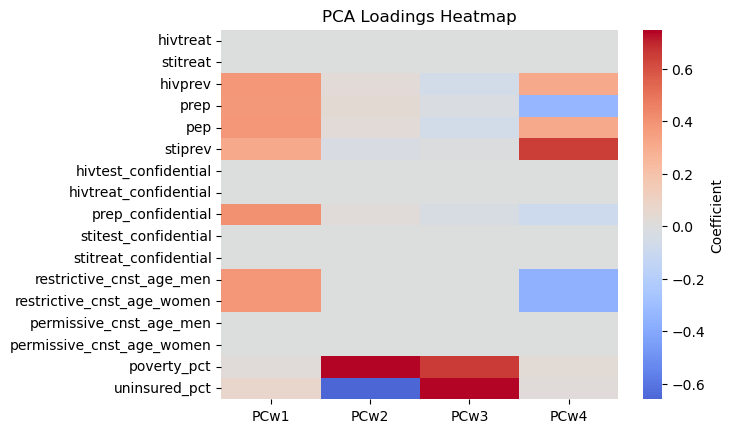

In [194]:
# heatmap of loadings, as before
sns.heatmap(
    loadings_within,
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Coefficient"})

plt.title("PCA Loadings Heatmap")
plt.show()

# Additional Year Lag (Exploratory and Unused)

In [195]:
consent_cols = ["hivprev", "prep", "pep"] # cols relating to minor consent to receive this care

# loop through each consent-related column and create a binary indicator
for col in consent_cols:
    merged[f"{col}_consent"] = (merged[col] == 0).astype(int)
    
# var indicating whether ANY consent policy is present
merged["consent_any"] = merged[[f"{c}_consent" for c in consent_cols]].max(axis=1)

# var = sum of positively consenting policies
merged["consent_sum"] = merged[[f"{c}_consent" for c in consent_cols]].sum(axis=1)

# var indicating FULL consent coverage
merged["consent_full"] = (merged["consent_sum"] == len(consent_cols)).astype(int)

# another copy of data
df = merged.copy()
df = df.sort_values(["Geography", "Year"])
df["policy_index"] = df["consent_sum"] + df["confidentiality"] # create an index for measurement

# year lags, so we can observe policies later than their active date
for lag in range(0, 3):  # t, t+1, t+2
    df[f"policy_lag{lag}"] = df.groupby("Geography")["policy_index"].shift(lag)

In [196]:
# run an OLS regression on lagged years

y = "HIV viral suppression" # target variable

controls = [
    "poverty_pct",
    "uninsured_pct"]

lags = ["policy_lag0", "policy_lag1", "policy_lag2"] # lag names

df_lag = df.dropna(subset=[y] + lags + controls).copy() # drop missing vals 

# run regression
model = smf.ols(
    f"""
    Q("{y}") ~ policy_lag0 + policy_lag1 + policy_lag2
    + poverty_pct + uninsured_pct + 
    C(Geography) + C(Year)
    """,
    data=df_lag
).fit(cov_type="cluster", cov_kwds={"groups": df_lag["Geography"]})

# print(model.summary())

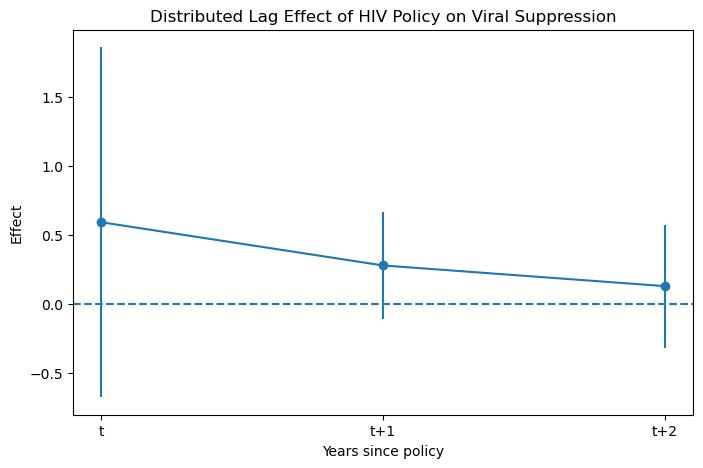

In [197]:
# lag plot
coefs = [model.params[l] for l in lags]
errors = [model.bse[l] for l in lags]

plt.figure(figsize=(8,5))
plt.errorbar(range(len(lags)), coefs, yerr=errors, fmt='o-')
plt.axhline(0, linestyle="--")
plt.xticks(range(len(lags)), ["t", "t+1","t+2"])
plt.title("Distributed Lag Effect of HIV Policy on Viral Suppression")
plt.xlabel("Years since policy")
plt.ylabel("Effect")
plt.show()

# Causal Forest Analysis

In [198]:
df = merged.copy() # another copy
y_col = "HIV viral suppression" # outcome
treatment_col = "hivtreat_confidential" # treatment--how does confidential treatment affect XYZ?

# columns of interest
# IF CHANGING TREATMENT, UNINCLUDE IT AND ADD IN THE MISSING VAR (PREVIOUS TREATMENT)
X_cols = [
    "hivprev",
    "prep",
    "pep",
    "stitest_confidential",
    "hivtest_confidential",
    "prep_confidential",
    "restrictive_cnst_age_men",
    "restrictive_cnst_age_women",
    "poverty_pct",
    "uninsured_pct"
]

# subset df to only include cols needed here
df_cf = df[[y_col, treatment_col] + X_cols].dropna().copy()

Y = df_cf[y_col].values # outcome as array
T = df_cf[treatment_col].values # treatment as array
X = df_cf[X_cols].values # controls as array

In [199]:
# initialize causal forest using Double Machine Learning (DML)
cf = CausalForestDML(
    model_y=RandomForestRegressor( # model to predict the Y given X
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=10),
    model_t=RandomForestRegressor( # model to predict the T given X
        n_estimators=200,
        max_depth=5,
        min_samples_leaf=10),
    n_estimators=400, # number of trees (pretty standard)
    min_samples_leaf=10, # minimum samples per leaf
    random_state=42)  # seed for reproducibility

cf.fit(Y, T, X=X) # fit forest model

# treatment effect (te); estimate of the by-state treatment effect
te = cf.effect(X)
df_cf["te"] = te # add estimated effects back into dataframe

In [200]:
# sanity check--average treatment effect (it's positive!)
print("Average Treatment Effect:", np.mean(te))
print("Std Dev:", np.std(te))
print("Min:", np.min(te))
print("Max:", np.max(te))

Average Treatment Effect: 17.25747663460034
Std Dev: 2.5876157276650122
Min: 8.292305675901158
Max: 20.663399316250675


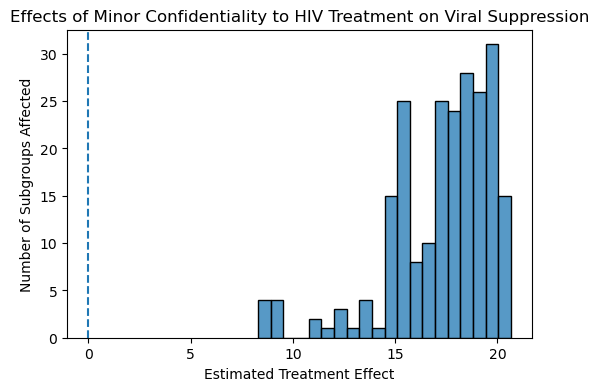

In [201]:
# plot our treatment (minor confidentiality to HIV care) by causal forest subgroups
plt.figure(figsize=(6,4))
sns.histplot(te, bins=20)

plt.axvline(0, linestyle="--")
plt.ylabel("Number of Subgroups Affected")
plt.xlabel("Estimated Treatment Effect")
plt.title("Effects of Minor Confidentiality to HIV Treatment on Viral Suppression")

plt.show()

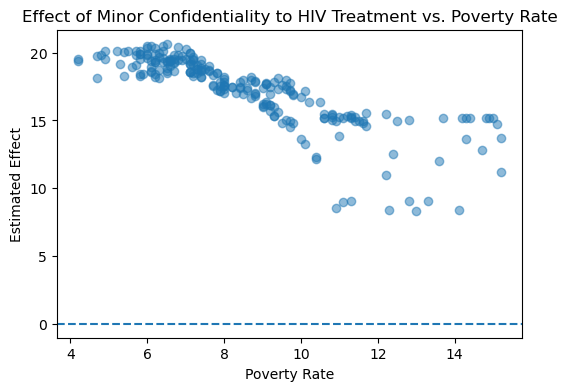

In [202]:
# for illustrative purposes, sort states by poverty rate + plot treatment effect
plt.figure(figsize=(6,4))
plt.scatter(df_cf["poverty_pct"], te, alpha=0.5) # change variable to examine here
plt.axhline(0, linestyle="--")
plt.xlabel("Poverty Rate")
plt.ylabel("Estimated Effect")
plt.title("Effect of Minor Confidentiality to HIV Treatment vs. Poverty Rate")
plt.show()